In [5]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("data/output/Traffic_Classification_Balanced.csv")  # replace with your CSV file

TARGET = "VIOLATION_FLAG"

# -----------------------------
# Column types based on AutoML info
# -----------------------------
categorical_cols = ["FAC", "FAC_B", "Day_Name"]
binary_categorical_cols = ["Is_Holiday", "Is_Weekend"]
numeric_cols = [col for col in df.columns if col not in categorical_cols + binary_categorical_cols + [TARGET]]

# -----------------------------
# Transformers
# -----------------------------
# CharGram vectorizer for categorical
class CharGramVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        self.vectorizers = {col: CountVectorizer(analyzer='char', ngram_range=(1,3)) for col in columns}

    def fit(self, X, y=None):
        for col in self.columns:
            self.vectorizers[col].fit(X[col].astype(str))
        return self

    def transform(self, X):
        transformed = [self.vectorizers[col].transform(X[col].astype(str)) for col in self.columns]
        from scipy.sparse import hstack
        return hstack(transformed)

# Label Encoder for binary categorical
class BinaryEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        self.encoders = {col: LabelEncoder() for col in columns}

    def fit(self, X, y=None):
        for col in self.columns:
            self.encoders[col].fit(X[col].astype(str))
        return self

    def transform(self, X):
        transformed = [self.encoders[col].transform(X[col].astype(str)).reshape(-1,1) for col in self.columns]
        return np.hstack(transformed)

# Numeric mean imputer
numeric_imputer = SimpleImputer(strategy='mean')

# -----------------------------
# Build the pipeline
# -----------------------------
pipeline = Pipeline([
    ("features", FeatureUnion(transformer_list=[
        ("categorical", CharGramVectorizer(categorical_cols)),
        ("binary_cat", BinaryEncoder(binary_categorical_cols)),
        ("numeric", Pipeline([
            ("imputer", numeric_imputer)
        ]))
    ])),
    ("scaler", StandardScaler(with_mean=False)),  # with_mean=False to support sparse matrices
    ("model", ExtraTreesClassifier(n_estimators=200, random_state=42))
])

# -----------------------------
# Train/test split
# -----------------------------
X = df.drop(TARGET, axis=1)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# -----------------------------
# Fit and evaluate
# -----------------------------
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9998666461506899


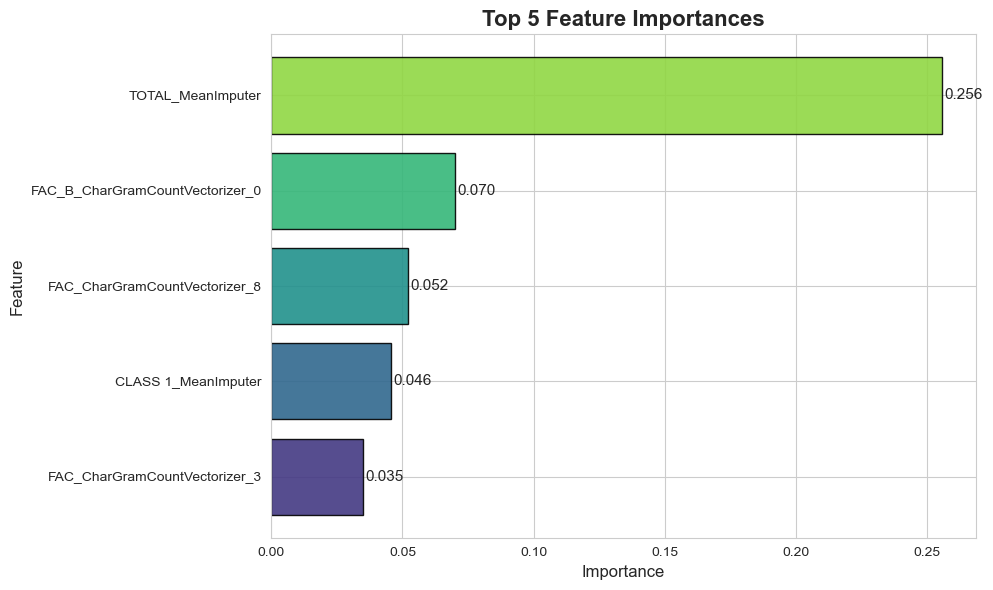

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Feature names
features = [
    "TOTAL_MeanImputer",
    "FAC_B_CharGramCountVectorizer_0",
    "FAC_CharGramCountVectorizer_8",
    "CLASS 1_MeanImputer",
    "FAC_CharGramCountVectorizer_3",
    "Buses_MeanImputer",
    "EZPASS_MeanImputer",
    "Day_Name_CharGramCountVectorizer_2",
    "FAC_CharGramCountVectorizer_5",
    "CLASS 9_MeanImputer",
    "FAC_B_CharGramCountVectorizer_1",
    "CLASS 4_MeanImputer",
    "CLASS 8_MeanImputer",
    "FAC_B_CharGramCountVectorizer_2",
    "Day_Name_CharGramCountVectorizer_6",
    "LANE_MeanImputer",
    "FAC_CharGramCountVectorizer_0",
    "Small_T_MeanImputer",
    "Day_Name_CharGramCountVectorizer_4",
    "VIOLATION_MeanImputer",
    "Is_Weekend_ModeCatImputer_LabelEncoder",
    "FAC_CharGramCountVectorizer_7",
    "Day_Name_CharGramCountVectorizer_1",
    "FAC_B_CharGramCountVectorizer_7",
    "Day_Name_CharGramCountVectorizer_0",
    "CASH_MeanImputer",
    "CLASS 2_MeanImputer",
    "FAC_CharGramCountVectorizer_4",
    "FAC_B_CharGramCountVectorizer_4",
    "FAC_B_CharGramCountVectorizer_6",
    "CLASS 5_MeanImputer",
    "FAC_CharGramCountVectorizer_6",
    "Day_Name_CharGramCountVectorizer_5",
    "FAC_CharGramCountVectorizer_1",
    "Day_Name_CharGramCountVectorizer_3",
    "Is_Holiday_ModeCatImputer_LabelEncoder",
    "CLASS 3_MeanImputer",
    "Autos_MeanImputer",
    "FAC_B_CharGramCountVectorizer_3",
    "FAC_B_CharGramCountVectorizer_5",
    "Large_T_MeanImputer",
    "CLASS 7_MeanImputer",
    "CLASS 11_MeanImputer",
    "CLASS 6_MeanImputer",
    "FAC_CharGramCountVectorizer_2"
]

# Importance values
importance_values = [
    0.2559446915467637,0.06991317785841292,0.052102307543480324,0.04566163359546717,
    0.03485752624190184,0.034277009568709826,0.03159268532426846,0.03009340048102718,
    0.026643024461126874,0.020694874175086166,0.0206745245104524,0.01625478273739553,
    0.013222018923127693,0.011765534959483384,0.010882753759229303,0.01023066520986326,
    0.009832757622751287,0.009485168750988109,0.008680625589399893,0.008082515271470454,
    0.007039216836982918,0.006381786775326653,0.005473975678522861,0.00482602271356997,
    0.004497149006536586,0.004230397343478025,0.0038832672469157827,0.0035672056331916566,
    0.0035048077017713814,0.0032730081733950245,0.0029248203580725697,0.002897528201833387,
    0.002813305424128595,0.002647575386104362,0.002185925981423879,0.002057772849067984,
    0.0017679123020335062,0.0015502211058757438,0.0012801954326544258,0.0008016403349481759,
    0.0007239835914023624,0.0001379114181238074,0,0,0
]

# -------------------------------
# Trim lists to the same length
# -------------------------------
min_length = min(len(features), len(importance_values))
features = features[:min_length]
importance_values = importance_values[:min_length]

# -------------------------------
# Create DataFrame
# -------------------------------
df = pd.DataFrame({
    "Feature": features,
    "Importance": importance_values
})

# -------------------------------
# Select top 5 features
# -------------------------------
top5 = df.sort_values(by="Importance", ascending=False).head(5)

# -------------------------------
# Plot horizontal bar chart
# -------------------------------
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

colors = sns.color_palette("viridis", len(top5))[::-1]  # Gradient colors
bars = plt.barh(top5["Feature"], top5["Importance"], color=colors, edgecolor='k', alpha=0.9)

# Annotate values
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', fontsize=11)

plt.title("Top 5 Feature Importances", fontsize=16, weight='bold')
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.gca().invert_yaxis()  # Largest on top
plt.tight_layout()
plt.show()
